In [ ]:
import pandas as pd
import sqlalchemy as db
from sqlalchemy import create_engine, func
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')
engine = create_engine('sqlite:///train.db')

conn = engine.connect()
metadata = db.MetaData()


In [ ]:
df.to_sql(
    "train",
    con=engine,
    if_exists="replace",
    index=False
)

1460

In [ ]:
train = db.Table(
    'Train', metadata, autoload_with=engine
)

In [ ]:
query = (
    db.select(
        train.c.Neighborhood,
        func.avg(train.c.SalePrice).label('mean_price')
    )
    .group_by(train.c.Neighborhood)
    .order_by('mean_price')
        )
result = conn.execute(query).mappings().all()

sorted_neighborhoods = [row.Neighborhood for row in result]
sorted_mean_prices = [row.mean_price for row in result]

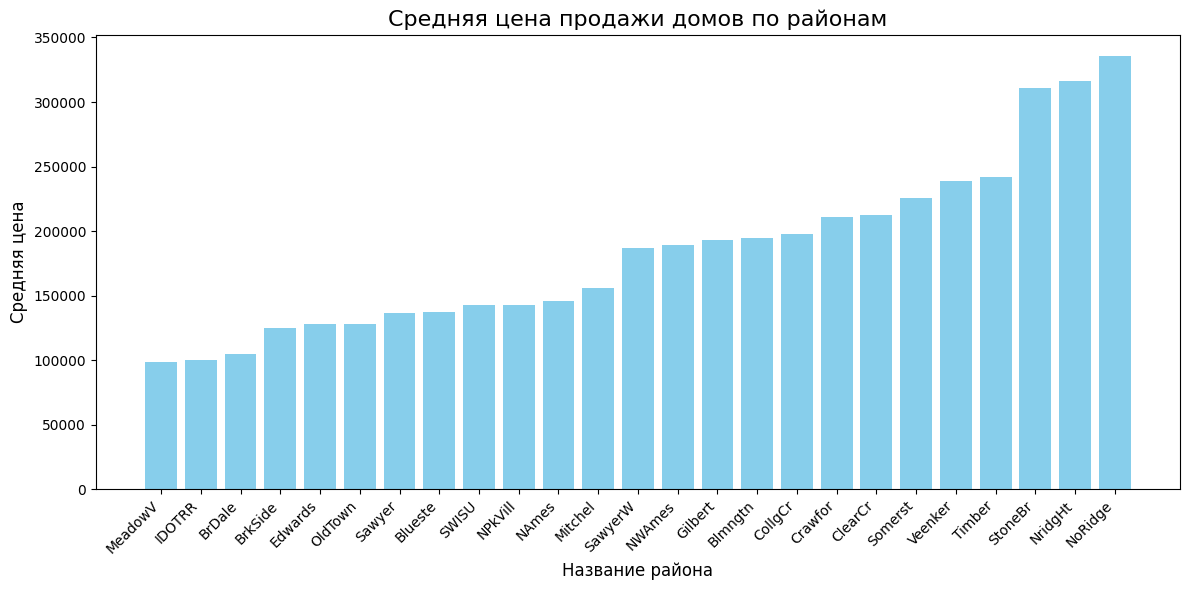

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(sorted_neighborhoods, sorted_mean_prices, color='skyblue')
plt.title('Средняя цена продажи домов по районам', fontsize=16)
plt.xlabel('Название района', fontsize=12)
plt.ylabel('Средняя цена', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


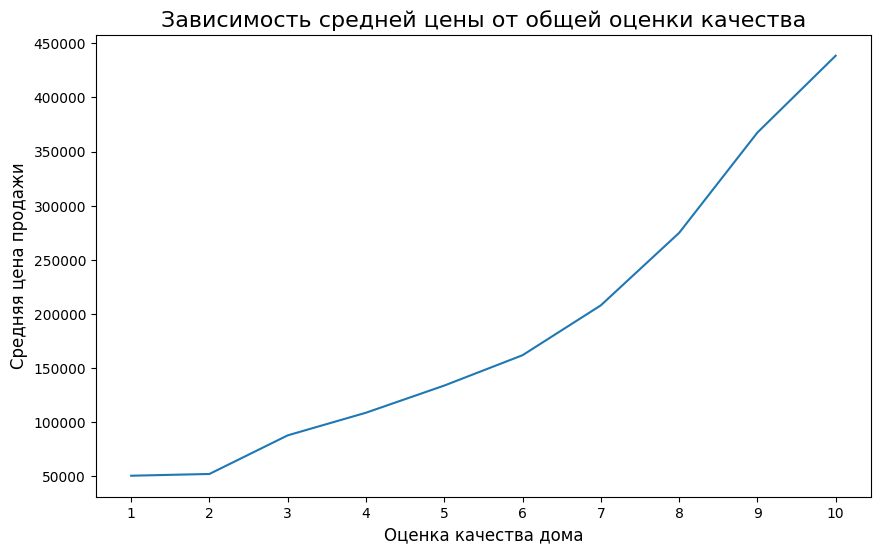

In [ ]:
avgprice = df[["OverallQual", "SalePrice"]].groupby("OverallQual").agg("mean")
plt.figure(figsize=(10, 6))
plt.plot(avgprice)
plt.title("Зависимость средней цены от общей оценки качества", fontsize=16)
plt.xlabel("Оценка качества дома", fontsize=12)
plt.ylabel("Средняя цена продажи", fontsize=12)
plt.xticks(range(1, 11))
plt.show()

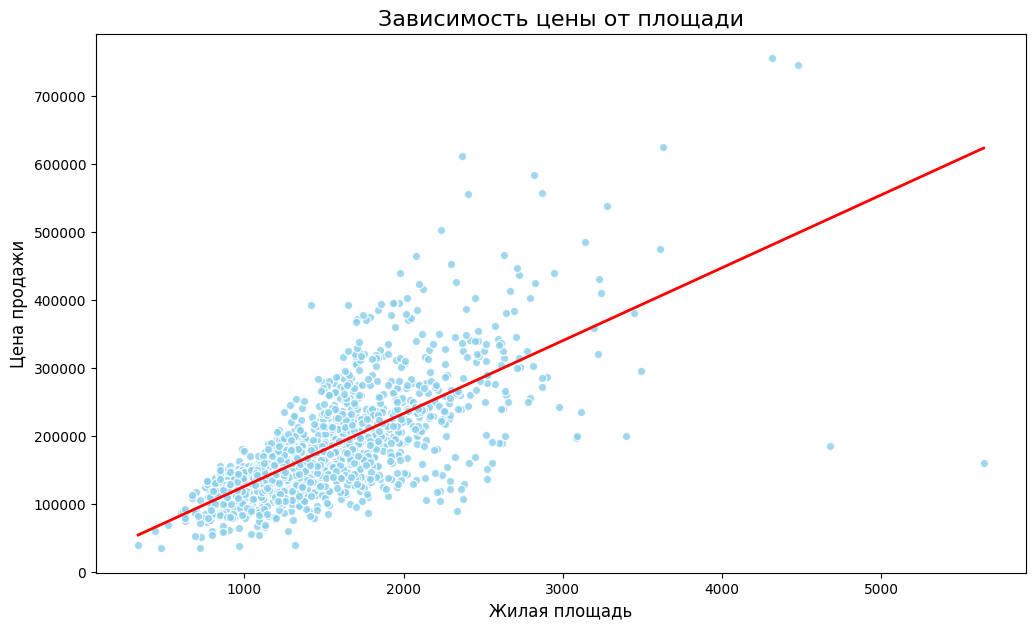

In [ ]:
plt.figure(figsize=(12, 7))

sns.regplot(
    data=df,
    x="GrLivArea",
    y="SalePrice",
    ci = None,
    scatter_kws={"color": "skyblue", "edgecolor": "white"},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Зависимость цены от площади", fontsize=16)
plt.xlabel("Жилая площадь", fontsize=12)
plt.ylabel("Цена продажи", fontsize=12)

plt.show()

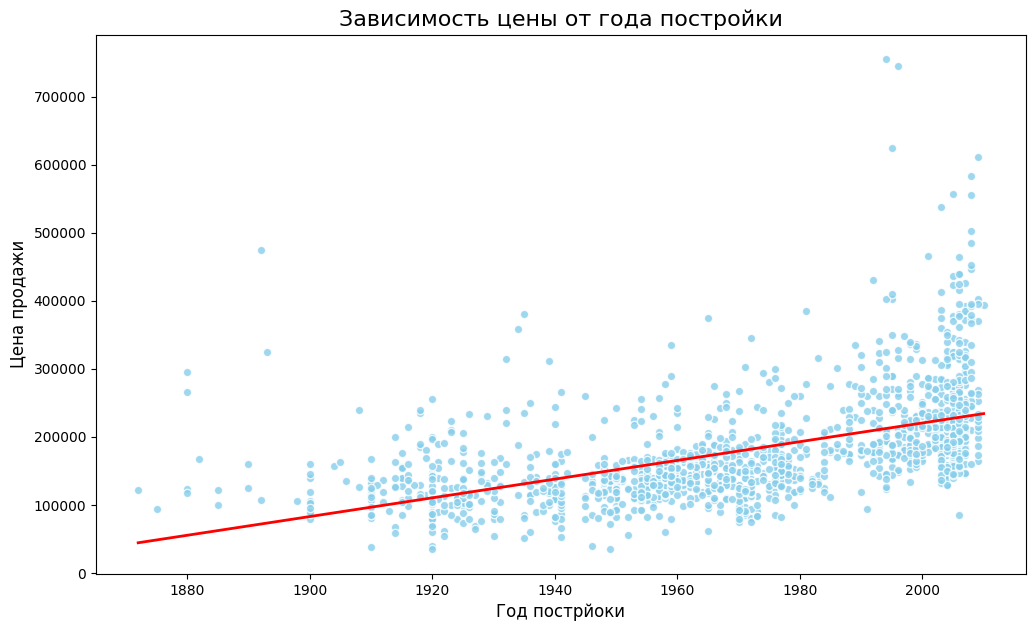

In [ ]:
plt.figure(figsize=(12, 7))

sns.regplot(
    data=df,
    x="YearBuilt",
    y="SalePrice",
    ci = None,
    scatter_kws={"color": "skyblue", "edgecolor": "white"},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Зависимость цены от года постройки", fontsize=16)
plt.xlabel("Год пострйоки", fontsize=12)
plt.ylabel("Цена продажи", fontsize=12)

plt.show()

In [24]:
avg_neighborhood = df.groupby("Neighborhood")["SalePrice"].mean()
df["Neighborhood_Num"] = df["Neighborhood"].map(avg_neighborhood)

factors = ["OverallQual", "Neighborhood_Num", "GrLivArea", "YearBuilt"]

for factor in factors:

    df["Group"] = pd.qcut(df[factor], 4, labels=False)

    low_price = df[df["Group"] == 0]["SalePrice"].mean()
    high_price = df[df["Group"] == 3]["SalePrice"].mean()

    print(f"{factor}: цена дома с высокими значениями по данному фактору выше в {high_price / low_price:.2f} раза")

OverallQual: цена дома с высокими значениями по данному фактору выше в 2.43 раза
Neighborhood_Num: цена дома с высокими значениями по данному фактору выше в 2.11 раза
GrLivArea: цена дома с высокими значениями по данному фактору выше в 2.17 раза
YearBuilt: цена дома с высокими значениями по данному фактору выше в 1.84 раза


In [23]:
# Для анализа было выбрано 4 фактора, значения которых явно влияют на цену согласно графикам.
# Чтобы проранжировать факторы, было принято решение разделить дома на 4 равные группы по каждому фактору:
# от домов с самыми низкими значениями по данному фактору до домов с самыми высокими значениями по данному фактору.
# После чего мы нашли среднюю цену на дома для групп с самыми низкими и самыми высокими значениями.
# И разделили среднюю цену группы с высокими значениями на группу с низкими значениям.
# Если предположить, что тем больше разница в цене, то тем больше фактор влияет на цену, то топ-4 фактора выглядят так:
# 1. OverallQual
# 2. GrLivArea
# 3. Neighborhood
# 4. YearBuilt